In [1]:
# Basic libraries
import os
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import nilearn.plotting as plotting  # Neuroimaging visualization

# Statistical analysis
import scipy.stats as stats
from scipy.stats import shapiro  # Normality check
from scipy.stats import mannwhitneyu  # Non-parametric test for un-normal distribution
from scipy.stats import ks_2samp  # Kolmogorov-Smirnov (K-S) Test
from scipy.stats import ttest_ind, spearmanr  # Other statistical tests

# Machine Learning
from sklearn.linear_model import LassoCV

# Neuroimaging utilities
import hcp_utils as hcp  # HCP dataset utility

# Pandas options
pd.options.mode.chained_assignment = None  # Hide long warnings

# Matplotlib inline for Jupyter notebooks
%matplotlib inline


pixdim[1,2,3] should be non-zero; setting 0 dims to 1


In [2]:
file_path = "parcellations"
file_list = os.listdir(file_path)
mmp = [] # Glasser 2016 which partitions each hemisphere into 180 regions
ca = [] # Cole-Anticevic 2019 which further partitions each hemisphere into ~350 regions
for i in file_list:
    if "mmp" in i:
        mmp_file = np.load(file_path + "/" + i)
        if mmp_file.shape == (3600, 379):
            mmp.append(np.load(file_path + "/" + i))

In [3]:
np.load("parcellations/sub-193845_task-rest_parcellation-ca_timeseries.npy").shape

(3600, 718)

In [4]:
open_access_data = pd.read_csv("Behavioral Data/Behavioral_Data.csv")
restricted_data = pd.read_csv("Behavioral Data/RESTRICTED_BEHAVIORAL_DATA.csv")
subject_data = open_access_data.merge(restricted_data, how = 'inner', on = 'Subject')

file_path = "parcellations"
file_list = os.listdir(file_path)
mmp = {}
ca = {}
for filename in file_list:
    subject_id = filename[4:10]

    if subject_id.isdigit():
        subject_id = int(subject_id)

        if "mmp" in filename:
            mmp_file = np.load(file_path + "/" + filename)
            if mmp_file.shape == (3600, 379):
                mmp[subject_id] = mmp_file
        if "ca" in filename:
            ca_file = np.load(file_path + "/" + filename)
            if ca_file.shape == (3600, 718):
                ca[subject_id] = ca_file

mmp_data = pd.DataFrame({
    'Subject': list(mmp.keys()),
    'Brain_Data': list(mmp.values())  # (3600, 379) arrays
})


mmp_data = subject_data.merge(mmp_data, on='Subject', how='inner')

In [5]:
mmp_data.head()

,Subject,Release,Acquisition,Gender,Age,3T_Full_MR_Compl,T1_Count,T2_Count,3T_RS-fMRI_Count,3T_RS-fMRI_PctCompl,...,SSAGA_Times_Used_Cocaine,SSAGA_Times_Used_Hallucinogens,SSAGA_Times_Used_Opiates,SSAGA_Times_Used_Sedatives,SSAGA_Times_Used_Stimulants,SSAGA_Mj_Use,SSAGA_Mj_Ab_Dep,SSAGA_Mj_Age_1st_Use,SSAGA_Mj_Times_Used,Brain_Data
0,100610,S900,Q08,M,26-30,True,2,1,4,100.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,"[[2.3968613, 0.33524948, -0.15465337, 1.955118..."
1,102311,S500,Q06,F,26-30,True,1,1,4,100.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,"[[-0.13254918, 0.16243707, 0.300286, 0.6371644..."
2,102816,Q3,Q03,F,26-30,True,1,1,4,100.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.0,3.0,"[[0.19969857, -0.7308231, -0.46953073, 0.19398..."
3,104416,S900,Q09,F,31-35,True,2,2,4,100.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,4.0,3.0,"[[-0.58722323, -2.054348, -2.3991566, -0.60077..."
4,105923,MEG2,Q07,F,31-35,True,2,2,4,100.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,4.0,1.0,"[[0.4015313, -0.47590375, -0.058990948, -0.747..."


In [6]:
mmp_data["Handedness_Cat"] = mmp_data["Handedness"].apply(lambda x: 0 if x < 0 else 1)
hand_data = mmp_data[["Subject", "Gender", "Race", "Handedness", "Handedness_Cat"]]
hand_data

,Subject,Gender,Race,Handedness,Handedness_Cat
0,100610,M,White,85,1
1,102311,F,White,10,1
2,102816,F,Black or African Am.,100,1
3,104416,F,Asian/Nat. Hawaiian/Othr Pacific Is.,65,1
4,105923,F,White,35,1
...,...,...,...,...,...
167,943862,M,White,95,1
168,958976,M,White,85,1
169,966975,M,White,40,1
170,971160,M,White,80,1


In [7]:
left_handed = hand_data[hand_data['Handedness'] < 0] 
right_handed = hand_data[hand_data['Handedness'] > 0]

# Handedness statistics
pd.DataFrame([
    left_handed.describe()['Handedness'], 
    right_handed.describe()['Handedness'], 
    hand_data['Handedness'].describe()
], index=['Left-Handed', 'Right-Handed', 'Overall']).T

,Left-Handed,Right-Handed,Overall
count,13.000000,159.000000,172.000000
mean,-48.846154,79.622642,69.912791
std,34.104853,19.980585,40.129446
min,-100.000000,10.000000,-100.000000
25%,-75.000000,70.000000,65.000000
50%,-40.000000,85.000000,80.000000
75%,-30.000000,95.000000,95.000000
max,-5.000000,100.000000,100.000000


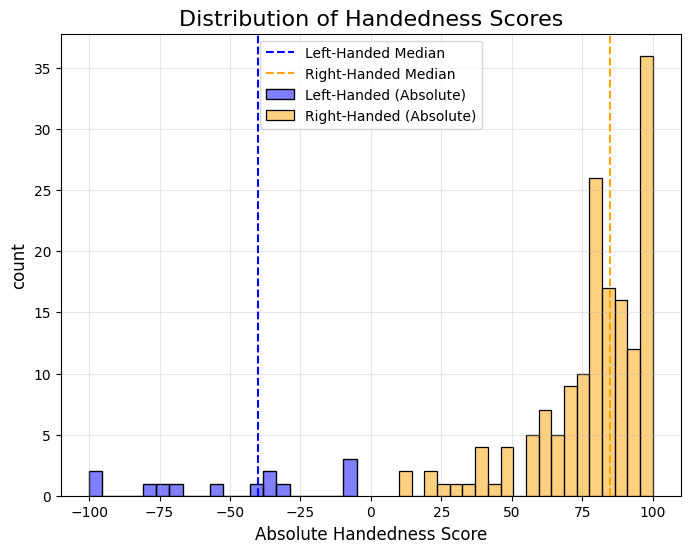

In [8]:
# Take absolute values of Handedness
left_handed_abs = left_handed['Handedness'].abs()
right_handed_abs = right_handed['Handedness'].abs()

plt.figure(figsize=(8, 6))
sns.histplot(left_handed['Handedness'], color='blue', label='Left-Handed (Absolute)', kde=False, bins=20, alpha=0.5)
sns.histplot(right_handed['Handedness'], color='orange', label='Right-Handed (Absolute)', kde=False, bins=20, alpha=0.5)


# mark medians
plt.axvline(left_handed['Handedness'].median(), color='blue', linestyle='--', label='Left-Handed Median')
plt.axvline(right_handed['Handedness'].median(), color='orange', linestyle='--', label='Right-Handed Median')

# Labels and title
plt.xlabel('Absolute Handedness Score', fontsize=12)
plt.ylabel('count', fontsize=12)
plt.title('Distribution of Handedness Scores', fontsize=16)
plt.legend()

plt.grid(alpha=0.3)
plt.show()

In [9]:
mmp_regions = list(hcp.mmp.labels.values())[1:]
len(mmp_regions)

379

In [10]:
mmp_regions

[np.str_('L_V1'),
 np.str_('L_MST'),
 np.str_('L_V6'),
 np.str_('L_V2'),
 np.str_('L_V3'),
 np.str_('L_V4'),
 np.str_('L_V8'),
 np.str_('L_4'),
 np.str_('L_3b'),
 np.str_('L_FEF'),
 np.str_('L_PEF'),
 np.str_('L_55b'),
 np.str_('L_V3A'),
 np.str_('L_RSC'),
 np.str_('L_POS2'),
 np.str_('L_V7'),
 np.str_('L_IPS1'),
 np.str_('L_FFC'),
 np.str_('L_V3B'),
 np.str_('L_LO1'),
 np.str_('L_LO2'),
 np.str_('L_PIT'),
 np.str_('L_MT'),
 np.str_('L_A1'),
 np.str_('L_PSL'),
 np.str_('L_SFL'),
 np.str_('L_PCV'),
 np.str_('L_STV'),
 np.str_('L_7Pm'),
 np.str_('L_7m'),
 np.str_('L_POS1'),
 np.str_('L_23d'),
 np.str_('L_v23ab'),
 np.str_('L_d23ab'),
 np.str_('L_31pv'),
 np.str_('L_5m'),
 np.str_('L_5mv'),
 np.str_('L_23c'),
 np.str_('L_5L'),
 np.str_('L_24dd'),
 np.str_('L_24dv'),
 np.str_('L_7AL'),
 np.str_('L_SCEF'),
 np.str_('L_6ma'),
 np.str_('L_7Am'),
 np.str_('L_7PL'),
 np.str_('L_7PC'),
 np.str_('L_LIPv'),
 np.str_('L_VIP'),
 np.str_('L_MIP'),
 np.str_('L_1'),
 np.str_('L_2'),
 np.str_('L_3a'),
 

In [12]:
# Separate left and right regions
left_regions = [region for region in mmp_regions if region.startswith("L_") or "left" in region]
right_regions = [region for region in mmp_regions if region.startswith("R_") or "right" in region]

print("Left Regions:", left_regions)
print("Right Regions:", right_regions)
(len(left_regions), len(right_regions))

Left Regions: [np.str_('L_V1'), np.str_('L_MST'), np.str_('L_V6'), np.str_('L_V2'), np.str_('L_V3'), np.str_('L_V4'), np.str_('L_V8'), np.str_('L_4'), np.str_('L_3b'), np.str_('L_FEF'), np.str_('L_PEF'), np.str_('L_55b'), np.str_('L_V3A'), np.str_('L_RSC'), np.str_('L_POS2'), np.str_('L_V7'), np.str_('L_IPS1'), np.str_('L_FFC'), np.str_('L_V3B'), np.str_('L_LO1'), np.str_('L_LO2'), np.str_('L_PIT'), np.str_('L_MT'), np.str_('L_A1'), np.str_('L_PSL'), np.str_('L_SFL'), np.str_('L_PCV'), np.str_('L_STV'), np.str_('L_7Pm'), np.str_('L_7m'), np.str_('L_POS1'), np.str_('L_23d'), np.str_('L_v23ab'), np.str_('L_d23ab'), np.str_('L_31pv'), np.str_('L_5m'), np.str_('L_5mv'), np.str_('L_23c'), np.str_('L_5L'), np.str_('L_24dd'), np.str_('L_24dv'), np.str_('L_7AL'), np.str_('L_SCEF'), np.str_('L_6ma'), np.str_('L_7Am'), np.str_('L_7PL'), np.str_('L_7PC'), np.str_('L_LIPv'), np.str_('L_VIP'), np.str_('L_MIP'), np.str_('L_1'), np.str_('L_2'), np.str_('L_3a'), np.str_('L_6d'), np.str_('L_6mp'), np.s

(189, 189)

In [13]:
hcp.view_parcellation(hcp.mesh.inflated, hcp.mmp)

In [18]:
mmp_correlation_matrix_list = []
for i in range(mmp_data.shape[0]):
    person = mmp_data["Brain_Data"][i]
    #get matrix
    person_matrix = np.corrcoef(person.T)
    #append to list
    mmp_correlation_matrix_list.append(person_matrix)
#append to column
mmp_data["correlation_matrix"] = mmp_correlation_matrix_list

In [19]:
def feature_row_get(target):
    target_index = mmp_regions.index(target)
    target_row = mmp_data['correlation_matrix'].apply(lambda x: x[target_index])
    
    return target_row

# Function to extract features automatically
def extract_features(region_list, data):
    """
    Extracts the correlation matrix rows for each brain region in region_list.
    
    Parameters:
    - region_list: List of brain region names (e.g., ["L_MT", "L_4", "R_4"])
    - data: DataFrame containing "correlation_matrix"
    
    Returns:
    - DataFrame with extracted features
    """
    # Copy the relevant columns first
    feature_data = data[["Handedness", "Handedness_Cat", "correlation_matrix"]].copy()
    # print(feature_data.shape)

    # Compute the mean of the entire correlation matrix as a baseline feature
    feature_data["matrix_mean"] = data["correlation_matrix"].apply(lambda x: np.mean(x))

    # Apply feature_row_get() dynamically and store in a dictionary
    for region in region_list:
        feature_data[region] = feature_row_get(region)

    return feature_data


In [20]:
# Extract features for handedness prediction
feature_data = extract_features(mmp_regions, mmp_data)
feature_data

/var/folders/bz/8tkr7qg51_1bcjy3cf4g8fzc0000gn/T/ipykernel_58198/1867560258.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  feature_data[region] = feature_row_get(region)
/var/folders/bz/8tkr7qg51_1bcjy3cf4g8fzc0000gn/T/ipykernel_58198/1867560258.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  feature_data[region] = feature_row_get(region)
/var/folders/bz/8tkr7qg51_1bcjy3cf4g8fzc0000gn/T/ipykernel_58198/1867560258.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.i

,Handedness,Handedness_Cat,correlation_matrix,matrix_mean,L_V1,L_MST,L_V6,L_V2,L_V3,L_V4,...,diencephalon_right,hippocampus_left,hippocampus_right,pallidum_left,pallidum_right,putamen_left,putamen_right,thalamus_left,thalamus_right,brainStem
0,85,1,"[[1.0, 0.46619928616491757, 0.5387587799680043...",0.175993,"[1.0, 0.46619928616491757, 0.5387587799680043,...","[0.46619928616491757, 0.9999999999999998, 0.44...","[0.5387587799680041, 0.4499977040762726, 1.0, ...","[0.8892868416109532, 0.4980392488505337, 0.669...","[0.869789454122726, 0.496984255970309, 0.53679...","[0.8147514719478919, 0.5400295037559002, 0.457...",...,"[0.35503242298914717, 0.2099338262698585, 0.20...","[0.3707425600137387, 0.23266761769771335, 0.30...","[0.3645208696856842, 0.22235976940137983, 0.35...","[0.12714982306826506, 0.06748345035761996, 0.0...","[0.13308024868626978, 0.1077981888115347, 0.05...","[0.3100933161756262, 0.24881346059399678, 0.17...","[0.3265738264531844, 0.2825369441278569, 0.198...","[0.5864892059883535, 0.3648707037374211, 0.371...","[0.5582765289662259, 0.35101745169885495, 0.38...","[0.5856313541418544, 0.363891982671451, 0.3986..."
1,10,1,"[[1.0, 0.4145113094959292, 0.342818966658749, ...",0.186351,"[1.0, 0.4145113094959292, 0.342818966658749, 0...","[0.4145113094959292, 0.9999999999999998, 0.704...","[0.34281896665874906, 0.7047527617097026, 1.0,...","[0.6488255962501398, 0.724840686113523, 0.7825...","[0.6113703275460517, 0.7378185708491541, 0.708...","[0.5720238401844869, 0.7336501426408212, 0.666...",...,"[0.4709289268511789, 0.10776035647735094, 0.08...","[0.2879182701749582, 0.16885750108802908, 0.17...","[0.2866675631876025, 0.21960607335957785, 0.23...","[0.18765225174159839, 0.04342396605090036, 0.0...","[0.16063836306979595, 0.013452149788054339, 0....","[0.2989966594350158, 0.02963297790273026, -0.1...","[0.28908567047301875, -0.08507595951425063, -0...","[0.5825102955540145, 0.007198172227728307, -0....","[0.5496595299756764, -0.020745895635067197, -0...","[0.5698083573040247, 0.34655284202675646, 0.29..."
2,100,1,"[[0.9999999999999998, 0.2989986241314227, 0.52...",0.258471,"[0.9999999999999998, 0.2989986241314227, 0.524...","[0.2989986241314227, 1.0, 0.5510809248076038, ...","[0.5246834631760836, 0.5510809248076038, 1.0, ...","[0.8090802391751148, 0.5339015630405952, 0.784...","[0.7751268075554022, 0.5292534475702055, 0.692...","[0.7091369855773447, 0.49772635124286263, 0.55...",...,"[0.3763481696712148, 0.17556581932283635, 0.15...","[0.2900142576369598, 0.44922905563451815, 0.52...","[0.3312662521181269, 0.4720732520795355, 0.533...","[0.18502032428149845, 0.0435007869405236, 0.09...","[0.2555694990185411, 0.08001469690627191, 0.08...","[0.3608501034288935, 0.08720571776315682, 0.11...","[0.3666126674932228, 0.04576551554754129, 0.10...","[0.5161074827653371, 0.17155229937390812, 0.23...","[0.5746687762566225, 0.13914864892984888, 0.25...","[0.5656910983821719, 0.3687751577105434, 0.502..."
3,65,1,"[[0.9999999999999998, 0.5081583697070787, 0.59...",0.211318,"[0.9999999999999998, 0.5081583697070787, 0.596...","[0.5081583697070786, 0.9999999999999998, 0.613...","[0.5960509332794675, 0.6139467613552139, 1.0, ...","[0.7814169550548589, 0.6980576885742854, 0.783...","[0.7177598637023298, 0.6730018479886771, 0.592...","[0.5931971888110517, 0.624906692133618, 0.3732...",...,"[0.20001582138770246, -0.008832310693729608, -...","[0.14761707593432147, 0.18072463522352433, 0.1...","[0.1374744519481748, 0.2004803394442056, 0.185...","[0.10619929568834638, 0.05873361949050927, 0.0...","[0.13088559190339152, 0.12902723145355785, 0.1...","[0.2148320182060796, 0.008706104476269587, 0.0...","[0.22165574154445203, 0.032556552822297496, 0....","[0.521820363701444, 0.39598278258570213, 0.369...","[0.4775837813669714, 0.361452635371305, 0.3442...","[0.506131300140526, 0.48203909591560734, 0.494..."
4,35,1,"[[1.0, 0.5963831451011642, 0.6588621195832001,...",0.327927,"[1.0, 0.5963831451011642, 0.6588621195832001, ...","[0.5963831451011642,

### Statistical Analysis of Brain Symmetry (In general)

1. Compute interhemispheric correlations for homologous brain regions (left vs. right). For each left-right region pair, we used the Pearson correlation coefficient.

e.g. the correlation between "L-A1" and "R-A1"

       Correlation
count   189.000000
mean      0.862477
std       0.118418
min       0.370316
25%       0.807534
50%       0.904409
75%       0.948065
max       0.992144


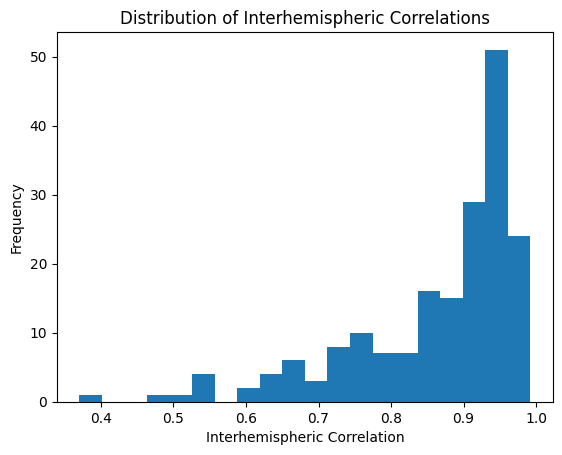

In [25]:
# Compute correlations between homologous left and right regions
corrs = []

for left, right in zip(left_regions, right_regions):
    left_values = np.array(feature_data[left].tolist()).astype(float)  # Convert object dtype to float
    right_values = np.array(feature_data[right].tolist()).astype(float)

    if left_values.ndim > 1:  # Flatten if multi-dimensional
        left_values = left_values.flatten()
    if right_values.ndim > 1:
        right_values = right_values.flatten()

    corr = np.corrcoef(left_values, right_values)[0, 1]  # Compute correlation
    corrs.append(corr)

# visualizing the correlations
symmetry_df = pd.DataFrame({"Region": left_regions, "Correlation": corrs})

print(symmetry_df.describe())

plt.hist(corrs, bins=20)
plt.xlabel("Interhemispheric Correlation")
plt.ylabel("Frequency")
plt.title("Distribution of Interhemispheric Correlations")
plt.show()

The median the correlations are high (0.9), meaning that brain activity is highly symmetric in resting state. Rsting-state fMRI data reflects strong interhemispheric symmetry instead of potential laterialization.

2. Compute the correlations for edges within each hemisphere, e.g. correlation between "R-A1" and "R-A2"

           Correlation                                                    \
                 count      mean       std       min       25%       50%   
Hemisphere                                                                 
Left           17766.0  0.705780  0.128784  0.238188  0.650310  0.737519   
Right          17766.0  0.706059  0.120658 -0.006229  0.654158  0.727253   

                                
                 75%       max  
Hemisphere                      
Left        0.793518  0.888648  
Right       0.797530  0.878956  


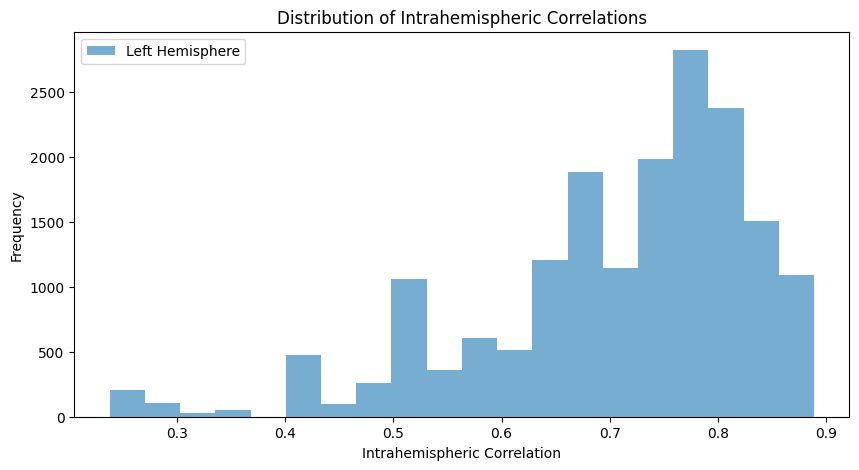

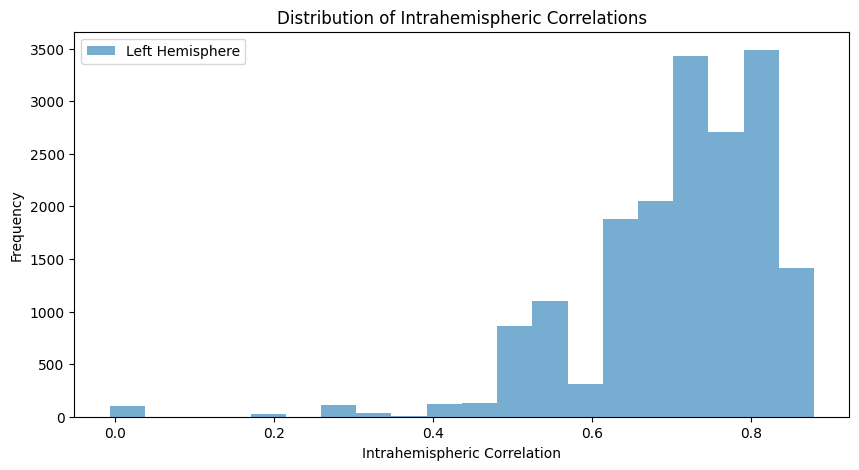

In [81]:
left_hemisphere_regions = [region for region in mmp_regions if region.startswith("L_") or "left" in region]
right_hemisphere_regions = [region for region in mmp_regions if region.startswith("R_") or "right" in region]

# Compute correlations for left hemisphere
left_intra_corrs = []
for i, region1 in enumerate(left_hemisphere_regions):
    for j, region2 in enumerate(left_hemisphere_regions):
        if i < j:
            values1 = np.array(feature_data[region1].tolist()).astype(float)
            values2 = np.array(feature_data[region2].tolist()).astype(float)
            corr = np.corrcoef(values1, values2)[0, 1]
            left_intra_corrs.append(corr)

# Compute correlations for right hemisphere
right_intra_corrs = []
for i, region1 in enumerate(right_hemisphere_regions):
    for j, region2 in enumerate(right_hemisphere_regions):
        if i < j:
            values1 = np.array(feature_data[region1].tolist()).astype(float)
            values2 = np.array(feature_data[region2].tolist()).astype(float)
            corr = np.corrcoef(values1, values2)[0, 1]
            right_intra_corrs.append(corr)

# Convert results to DataFrame for summary statistics
left_corr_df = pd.DataFrame({"Correlation": left_intra_corrs, "Hemisphere": "Left"})
right_corr_df = pd.DataFrame({"Correlation": right_intra_corrs, "Hemisphere": "Right"})
intrahemispheric_df = pd.concat([left_corr_df, right_corr_df])

# Print summary statistics
print(intrahemispheric_df.groupby("Hemisphere").describe())

# Plot histogram to visualize correlation distributions
plt.figure(figsize=(10, 5))
plt.hist(left_intra_corrs, bins=20, alpha=0.6, label="Left Hemisphere")
plt.xlabel("Intrahemispheric Correlation")
plt.ylabel("Frequency")
plt.title("Distribution of Intrahemispheric Correlations")
plt.legend()

# Plot histogram to visualize correlation distributions
plt.figure(figsize=(10, 5))
plt.hist(right_intra_corrs, bins=20, alpha=0.6, label="Right Hemisphere")
plt.xlabel("Intrahemispheric Correlation")
plt.ylabel("Frequency")
plt.title("Distribution of Intrahemispheric Correlations")
plt.legend()
plt.show()

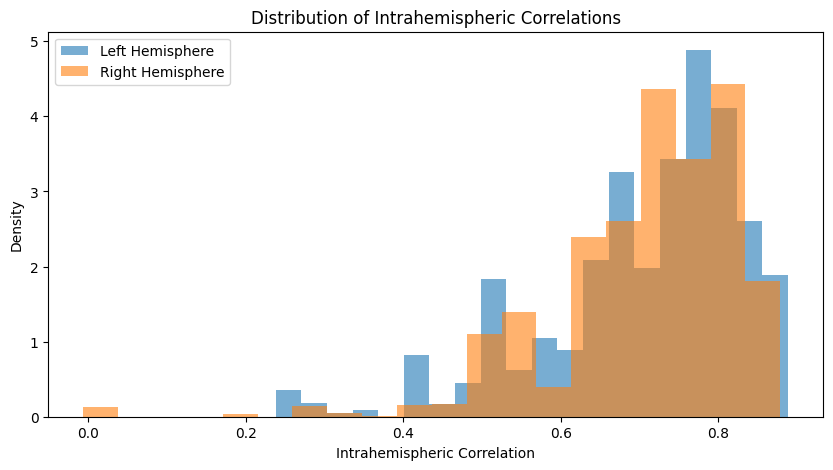

In [87]:
plt.figure(figsize=(10, 5))
plt.hist(left_intra_corrs, bins=20, alpha=0.6, label="Left Hemisphere", density=True)
plt.hist(right_intra_corrs, bins=20, alpha=0.6, label="Right Hemisphere", density=True)
plt.xlabel("Intrahemispheric Correlation")
plt.ylabel("Density")
plt.title("Distribution of Intrahemispheric Correlations")
plt.legend()

3. correlations all pairs of left and right regions correlations

Instead of only matching "L_A1" with "R_A1", this includes "L_A1" with "R_A2", "R_A3", ..., "R_PHT".

count    35721.000000
mean         0.691156
std          0.143870
min         -0.046312
25%          0.638780
50%          0.731549
75%          0.786193
max          0.888648
Name: Correlation, dtype: float64


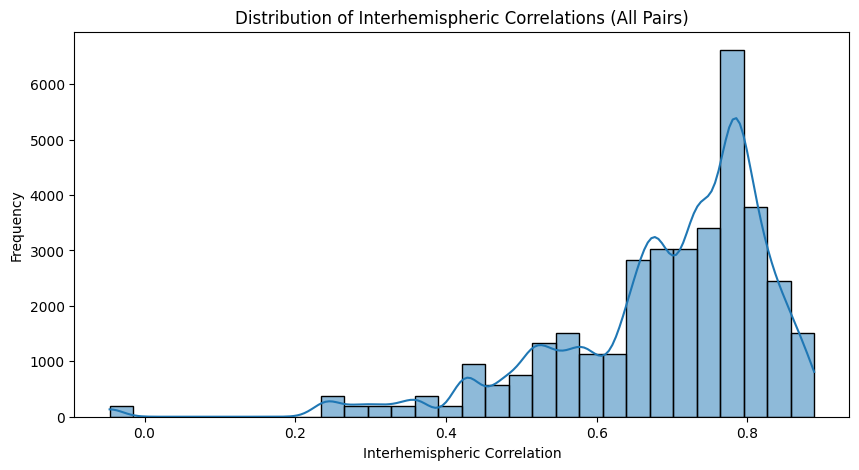

In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# List of left and right hemisphere regions
left_hemisphere_regions = [region for region in mmp_regions if region.startswith("L_") or 'left' in region]
right_hemisphere_regions = [region for region in mmp_regions if region.startswith("R_") or 'right' in region]

# Store correlations
interhemispheric_corrs = []

# Compute correlations for all left-right region pairs
for left in left_hemisphere_regions:
    for right in right_hemisphere_regions:
        left_values = np.array(feature_data[left].tolist()).astype(float)
        right_values = np.array(feature_data[right].tolist()).astype(float)

        corr = np.corrcoef(left_values, right_values)[0, 1]  # Compute correlation
        interhemispheric_corrs.append({"Left Region": left, "Right Region": right, "Correlation": corr})

# Convert to DataFrame
interhemispheric_df = pd.DataFrame(interhemispheric_corrs)

# Print summary statistics
print(interhemispheric_df["Correlation"].describe())


# Plot histogram to visualize correlation distribution
plt.figure(figsize=(10, 5))
sns.histplot(interhemispheric_df["Correlation"], bins=30)
plt.xlabel("Interhemispheric Correlation")
plt.ylabel("Frequency")
plt.title("Distribution of Interhemispheric Correlations (All Pairs)")
plt.show()

# # Heatmap to show pairwise correlations
# pivot_df = interhemispheric_df.pivot(index="Left Region", columns="Right Region", values="Correlation")

# plt.figure(figsize=(15, 12))
# sns.heatmap(pivot_df, cmap="coolwarm", center=0, annot=False, linewidths=0.5)
# plt.title("Interhemispheric Correlation Heatmap")
# plt.show()


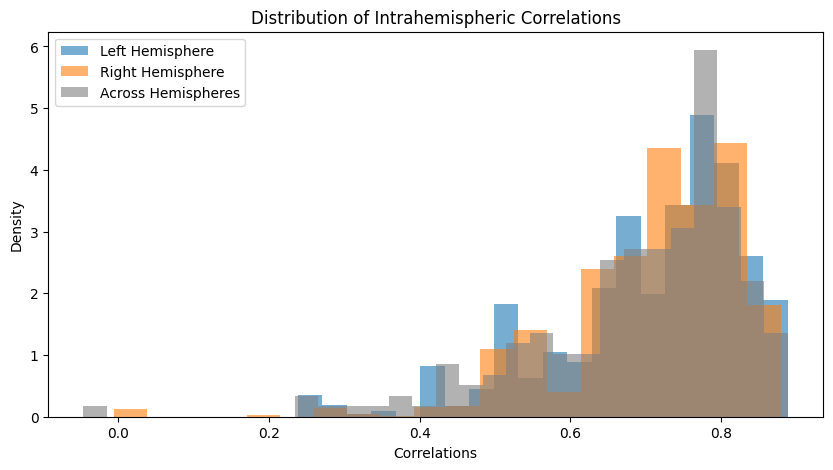

In [91]:
# Plot histogram to visualize correlation distribution

plt.figure(figsize=(10, 5))
plt.hist(left_intra_corrs, bins=20, alpha=0.6, label="Left Hemisphere", density=True)
plt.hist(right_intra_corrs, bins=20, alpha=0.6, label="Right Hemisphere", density=True)
plt.hist(interhemispheric_df["Correlation"], color='grey',bins=30, alpha=0.6, label= "Across Hemispheres", density=True)
plt.xlabel("Correlations")
plt.ylabel("Density")
plt.title("Distribution of Intrahemispheric Correlations")
plt.legend()
plt.show()



# plt.xlabel("Interhemispheric Correlation")
# plt.ylabel("Frequency")
# plt.title("Distribution of Interhemispheric Correlations (All Pairs)")
# plt.show()

### Statistical Analysis of Brain Symmetry (By Left- and Right-Handed Groups Separately)

Compare the distributions of brain activites for left- and right-handed individuals.
Perform t-test to check if there's a significant difference.

For left- and right-handed individuals, did the following for each pair of corresponding brain regions (e.g., "L_V1" & "R_V1", "L_4" & "R_4"):
* Extracts the values for that region in left-handed individuals.
* Computes the Pearson correlation coefficient between the left and corresponding right regions.
* stores the correlation values in 

In [57]:
# Separate data by handedness
left_handed = feature_data[feature_data["Handedness_Cat"] == 0]  # Adjust category accordingly
right_handed = feature_data[feature_data["Handedness_Cat"] == 1]

# Compute group-wise correlations

left_corrs = [
    np.corrcoef(np.array(left_handed[left].tolist(), dtype=float), 
                np.array(left_handed[right].tolist(), dtype=float))[0, 1]
    for left, right in zip(left_regions, right_regions)
]
right_corrs = [
    np.corrcoef(np.array(right_handed[left].tolist(), dtype=float), 
                np.array(right_handed[right].tolist(), dtype=float))[0, 1]
    for left, right in zip(left_regions, right_regions)
]

# Perform t-test
t_stat, p_value = ttest_ind(left_corrs, right_corrs)
print("T-statistic: ", t_stat, ', P-value: ', p_value)

# Perform Mann-Whitney U test
u_stat, p_value_u = mannwhitneyu(left_corrs, right_corrs, alternative="two-sided")
print("U-Stat: ", u_stat, ', P_value', p_value_u)


T-statistic:  1.6037147386688697 , P-value:  0.10961657304701984
U-Stat:  19478.0 , P_value 0.1279172606199262


P value is higher than 0.05. No significant difference is observed in symmetry between left- and right-handed subjects. We can infer from this that **brain activity is highly symmetric in resting state for left- and right-handed populations.**

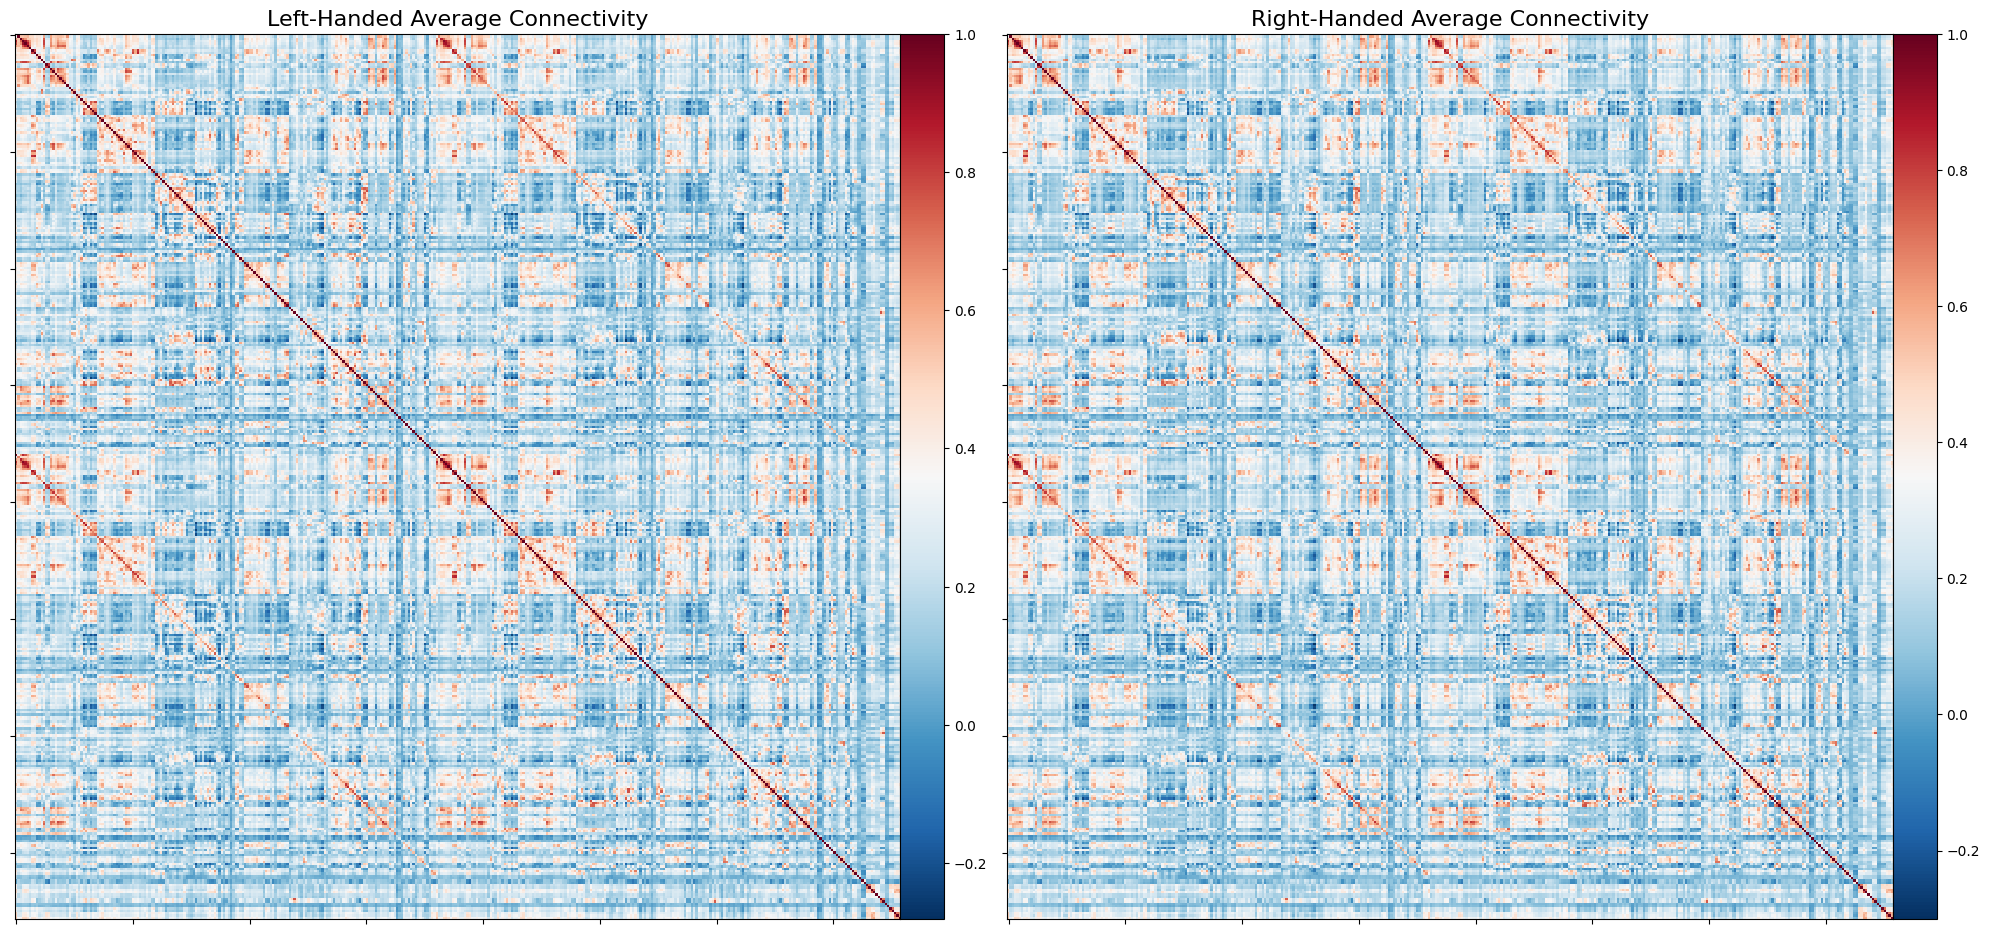

In [49]:
# Compute and plot the average correlation matrices for every pair of regions for left- and right-handers
left_avg_corr = np.mean(np.array(left_handed["correlation_matrix"].tolist()), axis=0) # shape: (379, 379)
right_avg_corr = np.mean(np.array(right_handed["correlation_matrix"].tolist()), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(20, 10))
plotting.plot_matrix(left_avg_corr, axes=axes[0], title="Left-Handed Average Connectivity")
plotting.plot_matrix(right_avg_corr, axes=axes[1], title="Right-Handed Average Connectivity")

plt.show()


In [60]:
feature_data

,Handedness,Handedness_Cat,correlation_matrix,matrix_mean,L_V1,L_MST,L_V6,L_V2,L_V3,L_V4,...,diencephalon_right,hippocampus_left,hippocampus_right,pallidum_left,pallidum_right,putamen_left,putamen_right,thalamus_left,thalamus_right,brainStem
0,85,1,"[[1.0, 0.46619928616491757, 0.5387587799680043...",0.175993,"[1.0, 0.46619928616491757, 0.5387587799680043,...","[0.46619928616491757, 0.9999999999999998, 0.44...","[0.5387587799680041, 0.4499977040762726, 1.0, ...","[0.8892868416109532, 0.4980392488505337, 0.669...","[0.869789454122726, 0.496984255970309, 0.53679...","[0.8147514719478919, 0.5400295037559002, 0.457...",...,"[0.35503242298914717, 0.2099338262698585, 0.20...","[0.3707425600137387, 0.23266761769771335, 0.30...","[0.3645208696856842, 0.22235976940137983, 0.35...","[0.12714982306826506, 0.06748345035761996, 0.0...","[0.13308024868626978, 0.1077981888115347, 0.05...","[0.3100933161756262, 0.24881346059399678, 0.17...","[0.3265738264531844, 0.2825369441278569, 0.198...","[0.5864892059883535, 0.3648707037374211, 0.371...","[0.5582765289662259, 0.35101745169885495, 0.38...","[0.5856313541418544, 0.363891982671451, 0.3986..."
1,10,1,"[[1.0, 0.4145113094959292, 0.342818966658749, ...",0.186351,"[1.0, 0.4145113094959292, 0.342818966658749, 0...","[0.4145113094959292, 0.9999999999999998, 0.704...","[0.34281896665874906, 0.7047527617097026, 1.0,...","[0.6488255962501398, 0.724840686113523, 0.7825...","[0.6113703275460517, 0.7378185708491541, 0.708...","[0.5720238401844869, 0.7336501426408212, 0.666...",...,"[0.4709289268511789, 0.10776035647735094, 0.08...","[0.2879182701749582, 0.16885750108802908, 0.17...","[0.2866675631876025, 0.21960607335957785, 0.23...","[0.18765225174159839, 0.04342396605090036, 0.0...","[0.16063836306979595, 0.013452149788054339, 0....","[0.2989966594350158, 0.02963297790273026, -0.1...","[0.28908567047301875, -0.08507595951425063, -0...","[0.5825102955540145, 0.007198172227728307, -0....","[0.5496595299756764, -0.020745895635067197, -0...","[0.5698083573040247, 0.34655284202675646, 0.29..."
2,100,1,"[[0.9999999999999998, 0.2989986241314227, 0.52...",0.258471,"[0.9999999999999998, 0.2989986241314227, 0.524...","[0.2989986241314227, 1.0, 0.5510809248076038, ...","[0.5246834631760836, 0.5510809248076038, 1.0, ...","[0.8090802391751148, 0.5339015630405952, 0.784...","[0.7751268075554022, 0.5292534475702055, 0.692...","[0.7091369855773447, 0.49772635124286263, 0.55...",...,"[0.3763481696712148, 0.17556581932283635, 0.15...","[0.2900142576369598, 0.44922905563451815, 0.52...","[0.3312662521181269, 0.4720732520795355, 0.533...","[0.18502032428149845, 0.0435007869405236, 0.09...","[0.2555694990185411, 0.08001469690627191, 0.08...","[0.3608501034288935, 0.08720571776315682, 0.11...","[0.3666126674932228, 0.04576551554754129, 0.10...","[0.5161074827653371, 0.17155229937390812, 0.23...","[0.5746687762566225, 0.13914864892984888, 0.25...","[0.5656910983821719, 0.3687751577105434, 0.502..."
3,65,1,"[[0.9999999999999998, 0.5081583697070787, 0.59...",0.211318,"[0.9999999999999998, 0.5081583697070787, 0.596...","[0.5081583697070786, 0.9999999999999998, 0.613...","[0.5960509332794675, 0.6139467613552139, 1.0, ...","[0.7814169550548589, 0.6980576885742854, 0.783...","[0.7177598637023298, 0.6730018479886771, 0.592...","[0.5931971888110517, 0.624906692133618, 0.3732...",...,"[0.20001582138770246, -0.008832310693729608, -...","[0.14761707593432147, 0.18072463522352433, 0.1...","[0.1374744519481748, 0.2004803394442056, 0.185...","[0.10619929568834638, 0.05873361949050927, 0.0...","[0.13088559190339152, 0.12902723145355785, 0.1...","[0.2148320182060796, 0.008706104476269587, 0.0...","[0.22165574154445203, 0.032556552822297496, 0....","[0.521820363701444, 0.39598278258570213, 0.369...","[0.4775837813669714, 0.361452635371305, 0.3442...","[0.506131300140526, 0.48203909591560734, 0.494..."
4,35,1,"[[1.0, 0.5963831451011642, 0.6588621195832001,...",0.327927,"[1.0, 0.5963831451011642, 0.6588621195832001, ...","[0.5963831451011642,

### Statistical Analysis on Region-to-Handedness Correlations

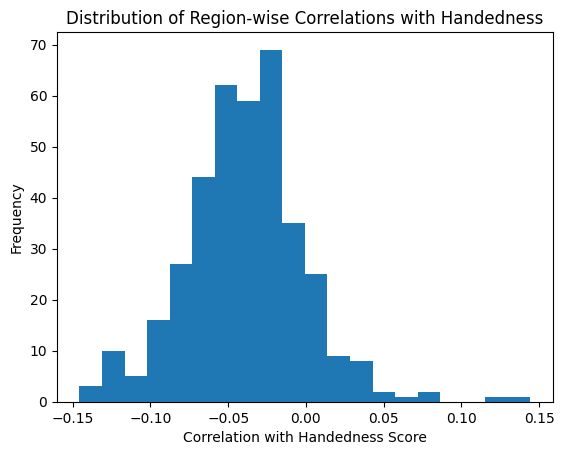

              Region  Correlation
288            R_Pir     0.144309
175           L_TE1m     0.116918
110           L_AAIC     0.083266
290           R_AAIC     0.081637
365  cerebellum_left     0.058738
203            R_PSL     0.051261
343            R_s32     0.044803
83          L_a9-46v     0.038398
159           L_31pd     0.032610
199            R_LO2     0.031797
       Region  Correlation
250     R_10d    -0.119986
170     L_TGv    -0.120179
81   L_p9-46v    -0.121491
168    L_p10p    -0.124604
261  R_p9-46v    -0.126149
116      L_EC    -0.126982
269     R_11l    -0.127394
90      L_13l    -0.131537
351   R_MBelt    -0.131855
301    R_STGa    -0.145630


In [68]:
# Compute mean connectivity per region across all its connections
region_means = np.mean(np.array(feature_data["correlation_matrix"].tolist()), axis=1)  # (172, 379)

# Compute correlations with handedness score
corrs_with_handedness = [spearmanr(region_means[:, i], feature_data["Handedness"])[0] for i in range(region_means.shape[1])]

# Convert to DataFrame for analysis
region_corr_df = pd.DataFrame({"Region": mmp_regions[1:], "Correlation": corrs_with_handedness[1:]})

# Plot the distribution of correlations
plt.hist(corrs_with_handedness, bins=20)
plt.xlabel("Correlation with Handedness Score")
plt.ylabel("Frequency")
plt.title("Distribution of Region-wise Correlations with Handedness")
plt.show()

# Show top correlated regions
region_corr_df = region_corr_df.sort_values(by="Correlation", ascending=False)
print(region_corr_df.head(10))  # Top 10 strongest positive correlations
print(region_corr_df.tail(10))  # Top 10 strongest negative correlations


Use LASSO to pick the most important features
* Lasso tends to drive some coefficients to exactly to zero because of L1 penalty. By shrinking coefficients, it prevents the model from fitting noise in the data.


In [63]:
# Flatten correlation matrices into 2D feature matrix
X = np.array(feature_data["correlation_matrix"].tolist()).reshape(len(feature_data), -1)
y = feature_data["Handedness_Cat"]  # Binary classification: Left (0) vs. Right (1)

# Apply LASSO regression
lasso = LassoCV(cv=5).fit(X, y)

# Identify important features
selected_features = np.where(lasso.coef_ != 0)[0]
print(f"Number of selected features: {len(selected_features)}")

# Map back to brain regions
selected_connections = [f"{mmp_regions[i // 379+1]} - {mmp_regions[i % 379+1]}" for i in selected_features]
print("Top predictive connections:", selected_connections[:10])


Number of selected features: 0
Top predictive connections: []
